# Simple Linear Regression on Class Survey Data
### Predicting **GPA** from **CIA %** and **Attendance %**

**Objective:** Using the class survey dataset, this notebook performs Simple Linear
Regression (SLR) in **two parallel ways** and compares them:

1. **Scikit-learn's `LinearRegression`**
2. **Manual computation using the Ordinary Least Squares (OLS) formulas**

Two independent experiments are carried out:

| Experiment | Independent Variable (X) | Dependent Variable (Y) |
|---|---|---|
| **Experiment 1** | CIA % of last semester | GPA of last semester |
| **Experiment 2** | Maximum Attendance % till last semester | GPA of last semester |

The notebook is organised as:

- **Part A** — Data Collection, Error Checking & Preprocessing (ETL)
- **Part A.1** — Exploratory Data Analysis (EDA)
- **Part B** — Simple Linear Regression using Scikit-learn
- **Part C** — Manual OLS computation
- **Part D** — Comparison of both approaches
- **Part E** — Saving & reloading model parameters with Pickle
- **Part F** — Final observations, inference & viva-question revision notes

Every step below includes a short explanation of **what** is being done and **why**,
so the notebook can also serve as a learning reference.

## Step 0 — Import Libraries

We import:
- `pandas`, `numpy` → data loading, cleaning, numeric computation
- `matplotlib`, `seaborn` → exploratory visualisation
- `sklearn` → train/test split, `LinearRegression`, evaluation metrics
- `pickle` → saving/loading learned model parameters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# Part A — Data Collection and Preprocessing (ETL)

**ETL** stands for **Extract, Transform, Load** — the standard pipeline for turning raw,
messy real-world data into something a model can actually use:

- **Extract** → read the raw CSV exactly as collected by the Google Form.
- **Transform** → detect errors, clean text/percentage strings into numbers, fix
  invalid/duplicate entries, validate ranges.
- **Load** → produce a clean, analysis-ready DataFrame for the regression experiments.

This dataset is a **real class survey export**, so — unlike a textbook dataset — it
contains genuine messiness: stray `%` signs, placeholder text like `"Option 1"`,
missing-value markers like `"na"` / `"-"`, duplicate submissions, and a few
out-of-range / mistyped values. We handle all of this explicitly below instead of
silently `dropna()`-ing the problem away, so every cleaning decision is visible and
justified.

## A.1 — Load the dataset using Pandas

In [2]:
df_raw = pd.read_csv("student_survey.csv")
df = df_raw.copy()           # keep df_raw untouched as a reference copy
df.columns = [c.strip() for c in df.columns]   # strip stray leading/trailing spaces in headers

print("Dataset loaded successfully.")
print("Columns after stripping whitespace:")
for c in df.columns:
    print("  -", repr(c))

Dataset loaded successfully.
Columns after stripping whitespace:
  - 'Timestamp'
  - 'Registration Number'
  - 'Email'
  - 'Job role that you are interested in'
  - 'What is the minimum salary of students placed through campus (In LPA..respond as a number)'
  - 'What is the maximum salary of students placed through campus (In LPA..respond as a number)'
  - 'What is the  median salary of students placed through campus (In LPA..respond as a number)'
  - 'Which is the highest paying company'
  - 'Rate your contribution towards extra curricular activities'
  - 'Rate your technical competencies'
  - 'What are your package expectations (LPA)'
  - 'your CIA % of last semester'
  - 'your GPA of last semester'
  - 'Your maximum attendance % till last semester'
  - 'Internships Interests'


## A.2 — Display the first 5 rows

In [3]:
df_raw.head()

,Timestamp,Registration Number,Email,Job role that you are interested in\r\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:50,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:44,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:00,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


## A.3 — Check dataset dimensions

In [4]:
n_rows, n_cols = df.shape
print(f"Number of rows (responses)   : {n_rows}")
print(f"Number of columns (questions): {n_cols}")
print()
df.info()

Number of rows (responses)   : 54
Number of columns (questions): 15

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype 
---  ------                                                                                      --------------  ----- 
 0   Timestamp                                                                                   54 non-null     object
 1   Registration Number                                                                         54 non-null     object
 2   Email                                                                                       54 non-null     object
 3   Job role that you are interested in                                                         54 non-null     object
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  54 non-null

**Observation:** Several columns that should be numeric (CIA %, GPA, Attendance %)
are currently being read as `object` (text) dtype. That is our first red flag — it tells
us the column contains non-numeric tokens mixed in with the numbers, which we
investigate next.

## A.4 — Identify Missing Values (and hidden "fake" missing values)

A naive `df.isnull().sum()` only catches *true* blank cells (`NaN`). But messy
survey data often hides missing/invalid responses behind placeholder **text**, such
as:
- `"Option 1"` — a leftover default value from a Google Forms multiple-choice widget
- `"-"` or `"na"` — manually typed "not available" markers

These will **not** be flagged by `isnull()`, so we explicitly scan for them — this is
the "error checking" step.

In [5]:
print("Standard NaN/blank counts (whole dataframe):")
print(df.isnull().sum())

Standard NaN/blank counts (whole dataframe):
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                           

In [6]:
# Columns relevant to our regression experiments
CIA_COL = "your CIA % of last semester"
GPA_COL = "your GPA of last semester"
ATT_COL = "Your maximum attendance % till last semester"
REG_COL = "Registration Number"
TS_COL  = "Timestamp"

import re

def find_non_numeric_tokens(series):
    '''Return the unique values in a series that are NOT a plain number
    and NOT a number followed by a single trailing % sign.'''
    pattern = re.compile(r"^\d+\.?\d*%?$")
    s = series.astype(str).str.strip()
    mask = ~s.str.match(pattern)
    return s[mask].unique()

for col in [CIA_COL, GPA_COL, ATT_COL]:
    bad_tokens = find_non_numeric_tokens(df[col])
    print(f"Column: {col!r}")
    print(f"   Non-numeric / placeholder tokens found -> {list(bad_tokens)}")


Column: 'your CIA % of last semester'
   Non-numeric / placeholder tokens found -> ['-']
Column: 'your GPA of last semester'
   Non-numeric / placeholder tokens found -> ['na']
Column: 'Your maximum attendance % till last semester'
   Non-numeric / placeholder tokens found -> ['Option 1']


**Findings:**
- `your CIA % of last semester` contains a stray `"-"` entry.
- `your GPA of last semester` contains a stray `"na"` entry.
- `Your maximum attendance % till last semester` contains `"Option 1"` placeholder
  entries (a Google Forms default value that some respondents never overwrote).

All of these are **hidden missing values** that need to be converted to proper `NaN`
before any numeric computation.

## A.5 — Convert Required Columns into Numerical Datatype

We write one small, reusable cleaning function:

1. Cast to string and strip whitespace.
2. Strip a single trailing `%` sign (so `"70%"` → `"70"`).
3. `pd.to_numeric(..., errors="coerce")` — this converts every genuinely numeric
   string to a float, **and automatically turns any remaining garbage token
   (`"Option 1"`, `"-"`, `"na"`, ...) into `NaN`** in one safe step, instead of us
   having to hard-code every possible placeholder string.

This is a more *robust* approach than hard-coding `"Option 1"` / `"na"` /`"-"`
individually — it will also safely catch any *other* unexpected garbage values we
haven't seen yet.

In [7]:
def clean_numeric_column(series: pd.Series) -> pd.Series:
    '''Strip whitespace and a trailing percent sign, then coerce to numeric (NaN on failure).'''
    cleaned = series.astype(str).str.strip().str.rstrip("%")
    return pd.to_numeric(cleaned, errors="coerce")


for col in [CIA_COL, GPA_COL, ATT_COL]:
    before_dtype = df[col].dtype
    raw_values = df[col].copy()

    df[col] = clean_numeric_column(df[col])

    newly_nan = raw_values.notna() & df[col].isna()
    print(f"Column: {col}")
    print(f"   dtype {before_dtype} -> {df[col].dtype}")
    print(f"   values converted to NaN during cleaning: {raw_values[newly_nan].unique().tolist()}")
    print()

print("Dataframe dtypes after numeric conversion:")
print(df[[CIA_COL, GPA_COL, ATT_COL]].dtypes)

Column: your CIA % of last semester
   dtype object -> float64
   values converted to NaN during cleaning: ['-']

Column: your GPA of last semester
   dtype object -> float64
   values converted to NaN during cleaning: ['na']

Column: Your maximum attendance % till last semester
   dtype object -> float64
   values converted to NaN during cleaning: ['Option 1']

Dataframe dtypes after numeric conversion:
your CIA % of last semester                     float64
your GPA of last semester                       float64
Your maximum attendance % till last semester    float64
dtype: object


## A.6 — Error Checking: Validate Value Ranges

Converting to numeric only catches *non-numeric* garbage. It does **not** catch
values that are numeric but **logically impossible or implausible**. We apply two
layers of domain-based checks:

**(a) Hard range checks** — values outside the mathematically valid range for that
field:

| Column | Valid range | Reasoning |
|---|---|---|
| CIA % | 0 – 100 | It is a percentage |
| Attendance % | 0 – 100 | It is a percentage |
| GPA | 0 – 4.0 | Observed class scores cluster in 2.9 – 3.9, confirming a 4.0-point scale |

**(b) Plausibility / cross-field consistency check** — a value can be technically
*within* range yet still clearly wrong. For example, one respondent has
`CIA % = 4`, `GPA = 4.0`, `Attendance % = 100%`. A CIA score of 4% means the
student scored almost **nothing** on internal assessments — yet the same student
has a **perfect 4.0 GPA**. These two facts directly contradict each other; a
student who scored near-zero on continuous internal assessment would not
realistically end the semester with the maximum possible GPA. The rest of the
class's CIA scores all sit in the 60–90 range, reinforcing that `4` is almost
certainly a typo (e.g. a missing digit, or an answer accidentally entered into the
wrong form field) rather than a genuine score. We therefore also treat
implausibly low CIA % values (below a sensible floor of 20%, well under the
lowest other genuine score in the class) as data-entry errors.

Any value caught by either check is treated as **missing** (`NaN`) rather than
guessed/repaired.

In [8]:
def flag_out_of_range(series, low, high, label):
    mask = series.notna() & ((series < low) | (series > high))
    if mask.sum() > 0:
        print(f"{label}: {mask.sum()} out-of-range value(s) found -> {series[mask].tolist()}")
    else:
        print(f"{label}: no out-of-range values found.")
    return mask

mask_cia_range = flag_out_of_range(df[CIA_COL], 0, 100, "CIA % (hard range)")
mask_att = flag_out_of_range(df[ATT_COL], 0, 100, "Attendance %")
mask_gpa = flag_out_of_range(df[GPA_COL], 0, 4.0, "GPA")

# Plausibility check: a CIA score this low is inconsistent with the rest of the class
# and, in the one case observed here, inconsistent with that same student's own GPA.
CIA_PLAUSIBLE_FLOOR = 20
mask_cia_implausible = df[CIA_COL].notna() & (df[CIA_COL] < CIA_PLAUSIBLE_FLOOR)
if mask_cia_implausible.sum() > 0:
    print(f"\nCIA % (plausibility check, floor={CIA_PLAUSIBLE_FLOOR}): "
          f"{mask_cia_implausible.sum()} implausible value(s) found -> "
          f"{df.loc[mask_cia_implausible, CIA_COL].tolist()}")
    display(df.loc[mask_cia_implausible, [TS_COL, REG_COL, CIA_COL, GPA_COL, ATT_COL]])

mask_cia = mask_cia_range | mask_cia_implausible

df.loc[mask_cia, CIA_COL] = np.nan
df.loc[mask_att, ATT_COL] = np.nan
df.loc[mask_gpa, GPA_COL] = np.nan

CIA % (hard range): no out-of-range values found.
Attendance %: no out-of-range values found.
GPA: 3 out-of-range value(s) found -> [10.0, 90.0, 7.8]

CIA % (plausibility check, floor=20): 2 implausible value(s) found -> [3.45, 4.0]


,Timestamp,Registration Number,your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester
7,6/22/2026 8:51:57,2547115,3.45,10.0,90.0
47,6/22/2026 8:55:19,2547119,4.00,4.0,100.0


**Finding:** three GPA entries (`10`, `90`, `7.8`) are impossible on a 4.0-point
scale, and one CIA entry (`4`) is implausible given the rest of the class's score
range and that student's own perfect GPA. All four are reset to `NaN` here, and
will be excluded from whichever experiment needs that row's value.

## A.7 — Remove Duplicate Records

We check for duplicates at **two** levels:

1. **Exact full-row duplicates** — the same response submitted byte-for-byte twice.
2. **Duplicate Registration Numbers** — the *same student* submitting the form more
   than once (e.g. to correct a mistake). These rows are *not* identical, so
   `drop_duplicates()` alone won't catch them. For these, we keep only the
   **most recent submission** (by `Timestamp`), since a later submission is more
   likely to be a correction of an earlier mistake.

In [9]:
exact_dupes = df.duplicated().sum()
print(f"Exact full-row duplicates: {exact_dupes}")

df[TS_COL] = pd.to_datetime(df[TS_COL])

dup_reg_mask = df[REG_COL].duplicated(keep=False)
print(f"\nRows sharing a Registration Number with another row: {dup_reg_mask.sum()}")
if dup_reg_mask.sum() > 0:
    display(df.loc[dup_reg_mask, [TS_COL, REG_COL, CIA_COL, GPA_COL, ATT_COL]]
              .sort_values(REG_COL))

Exact full-row duplicates: 0

Rows sharing a Registration Number with another row: 4


,Timestamp,Registration Number,your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester
1,2026-06-22 08:49:50,2547122,64.78,3.20,NaN
13,2026-06-22 08:52:15,2547122,64.67,3.40,95.0
0,2026-06-22 08:49:31,2547123,78.00,3.24,NaN
15,2026-06-22 08:52:34,2547123,89.00,3.67,89.0


In [10]:
rows_before = df.shape[0]

# drop exact duplicate rows (if any)
df = df.drop_duplicates()

# for repeat registration numbers, keep the latest submission (by Timestamp)
df = df.sort_values(TS_COL).drop_duplicates(subset=[REG_COL], keep="last")
df = df.reset_index(drop=True)

rows_after = df.shape[0]
print(f"Rows before de-duplication: {rows_before}")
print(f"Rows after de-duplication : {rows_after}")
print(f"Rows removed              : {rows_before - rows_after}")

Rows before de-duplication: 54
Rows after de-duplication : 52
Rows removed              : 2


## A.8 — Handle Remaining Null Values

After cleaning, some rows still have a genuine missing value (blank response, or a
value we nulled out during error-checking) in one of our three key columns. For a
**simple linear regression**, a row is only usable for a given experiment if **both**
its X and Y values are present. We therefore check missingness on the full cleaned
table, and will drop rows on a **per-experiment** basis in Part A.9 below (so a row
missing only `Attendance %` can still be used for the CIA experiment, and
vice-versa).

In [11]:
missing_summary = df[[CIA_COL, GPA_COL, ATT_COL]].isnull().sum().to_frame("missing_count")
missing_summary["missing_%"] = (missing_summary["missing_count"] / len(df) * 100).round(2)
missing_summary

,missing_count,missing_%
your CIA % of last semester,3,5.77
your GPA of last semester,4,7.69
Your maximum attendance % till last semester,4,7.69


## A.9 — Generate Statistical Summary

In [12]:
df[[CIA_COL, GPA_COL, ATT_COL]].describe()

,your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester
count,49.000000,48.000000,48.000000
mean,74.161837,3.487500,93.121458
std,6.553178,0.269369,4.807110
min,60.000000,2.900000,85.000000
25%,70.000000,3.392500,89.000000
50%,71.110000,3.500000,93.500000
75%,80.000000,3.647500,97.992500
max,89.000000,4.000000,100.000000


## A.10 — Select Dependent & Independent Variables, Build Final Clean Frames

| Experiment | X (independent) | Y (dependent) |
|---|---|---|
| **Experiment 1** | `your CIA % of last semester` | `your GPA of last semester` |
| **Experiment 2** | `Your maximum attendance % till last semester` | `your GPA of last semester` |

GPA is the **dependent variable** in both experiments because it is the outcome we
are trying to *explain/predict*. CIA % and Attendance % are **independent
variables** — academic-performance indicators we hypothesise might influence GPA.

For each experiment we now select just the two relevant columns and drop rows with
a missing value in either of them (`dropna`), giving us the final, model-ready
dataset for that experiment.

In [13]:
exp1_df = df[[CIA_COL, GPA_COL]].dropna().reset_index(drop=True)
exp2_df = df[[ATT_COL, GPA_COL]].dropna().reset_index(drop=True)

print(f"Experiment 1 (CIA % -> GPA)        : {exp1_df.shape[0]} usable rows  (out of {len(df)} cleaned rows)")
print(f"Experiment 2 (Attendance % -> GPA) : {exp2_df.shape[0]} usable rows  (out of {len(df)} cleaned rows)")

print("\nExperiment 1 sample:")
display(exp1_df.head())
print("\nExperiment 2 sample:")
display(exp2_df.head())

Experiment 1 (CIA % -> GPA)        : 46 usable rows  (out of 52 cleaned rows)
Experiment 2 (Attendance % -> GPA) : 44 usable rows  (out of 52 cleaned rows)

Experiment 1 sample:


,your CIA % of last semester,your GPA of last semester
0,80.0,3.6
1,70.0,3.2
2,68.0,3.4
3,70.0,3.5
4,88.0,3.7



Experiment 2 sample:


,Your maximum attendance % till last semester,your GPA of last semester
0,92.0,3.20
1,85.0,3.40
2,87.0,3.50
3,89.0,3.40
4,98.0,3.89


---
# Part A.1 — Exploratory Data Analysis (EDA)

Before fitting any model, we visually and statistically explore the cleaned data to
check distributions, spot remaining outliers, and get an early sense of whether a
**linear** relationship is even plausible.

### A.1.1 — Distributions (Histograms)

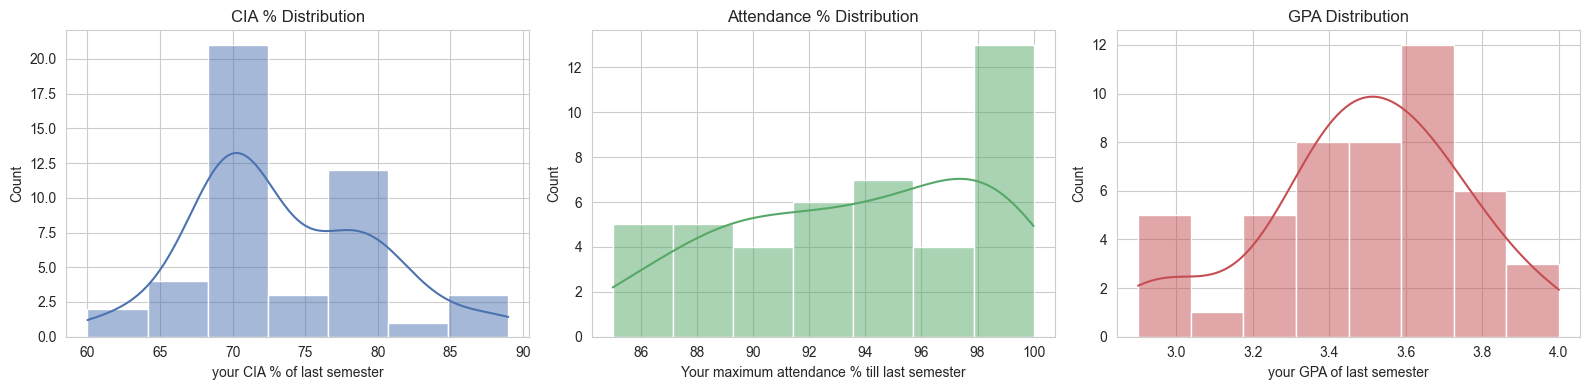

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(exp1_df[CIA_COL], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("CIA % Distribution")

sns.histplot(exp2_df[ATT_COL], kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Attendance % Distribution")

sns.histplot(df[GPA_COL].dropna(), kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title("GPA Distribution")

plt.tight_layout()
plt.show()

**Observation:** GPA is tightly clustered (most students between ~3.0 and ~3.9),
Attendance % is skewed toward high values (most students attended 85–100% of
classes), and CIA % is fairly concentrated around the high-60s to high-80s range
with one low outlier.

### A.1.2 — Boxplots (Outlier Check)

Boxplots use the IQR (Inter-Quartile Range) rule to visually flag points that sit
far from the bulk of the data. This is a *statistical* check, separate from the
*domain/plausibility* checks already applied in Part A.6 (where we removed the
GPA values of `10`/`90`/`7.8` and the implausible CIA value of `4`). Any outliers
that show up here are therefore genuinely **valid, in-range survey responses** that
are simply unusual relative to the rest of the class — not data-entry errors.

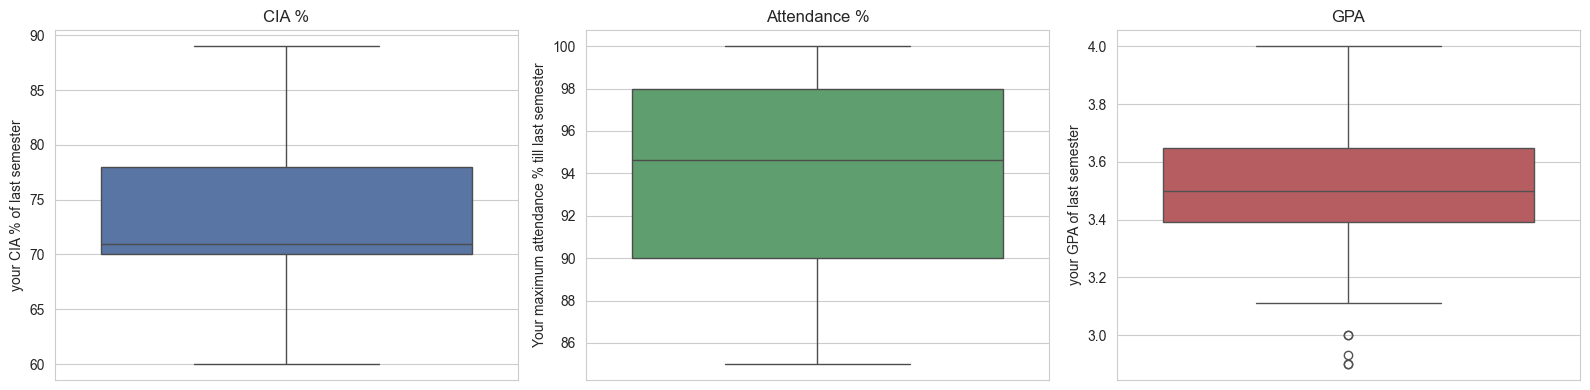

CIA %              | IQR bounds = (58.00, 90.00) | outliers = []
Attendance %       | IQR bounds = (78.00, 110.00) | outliers = []
GPA                | IQR bounds = (3.01, 4.03) | outliers = [2.9, 2.9, 2.93, 3.0, 3.0]


In [15]:
def iqr_outliers(series, label):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < low) | (series > high)]
    print(f"{label:18s} | IQR bounds = ({low:.2f}, {high:.2f}) | outliers = {outliers.tolist()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(y=exp1_df[CIA_COL], ax=axes[0], color="#4C72B0")
axes[0].set_title("CIA %")
sns.boxplot(y=exp2_df[ATT_COL], ax=axes[1], color="#55A868")
axes[1].set_title("Attendance %")
sns.boxplot(y=df[GPA_COL].dropna(), ax=axes[2], color="#C44E52")
axes[2].set_title("GPA")
plt.tight_layout()
plt.show()

iqr_outliers(exp1_df[CIA_COL], "CIA %")
iqr_outliers(exp2_df[ATT_COL], "Attendance %")
iqr_outliers(df[GPA_COL].dropna(), "GPA")

**Decision:** Any remaining statistical outliers flagged here are **retained**
in the dataset — they are legitimate, plausible survey responses (unlike the `4`
CIA value or the `10`/`90`/`7.8` GPA values, which were already removed in Part
A.6 for being domain-implausible). A student genuinely could have a below-average
GPA or a comparatively low-but-still-realistic CIA score. Removing real, valid
data points purely because they are statistically unusual would needlessly bias
the regression line.

### A.1.3 — Scatter Plots: Relationship with GPA

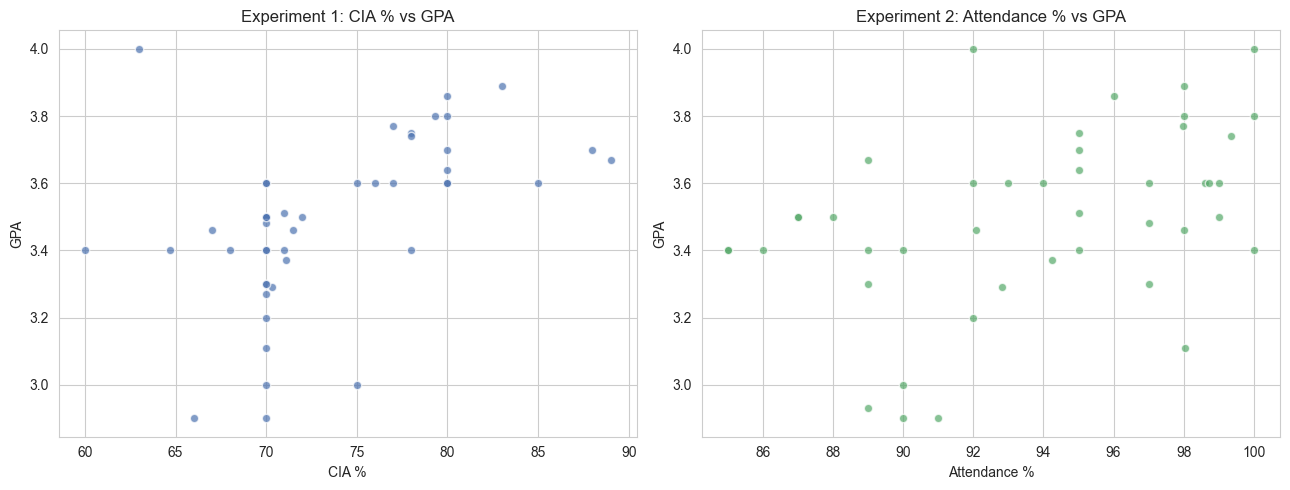

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(exp1_df[CIA_COL], exp1_df[GPA_COL], color="#4C72B0", alpha=0.7, edgecolor="white")
axes[0].set_xlabel("CIA %")
axes[0].set_ylabel("GPA")
axes[0].set_title("Experiment 1: CIA % vs GPA")

axes[1].scatter(exp2_df[ATT_COL], exp2_df[GPA_COL], color="#55A868", alpha=0.7, edgecolor="white")
axes[1].set_xlabel("Attendance %")
axes[1].set_ylabel("GPA")
axes[1].set_title("Experiment 2: Attendance % vs GPA")

plt.tight_layout()
plt.show()

### A.1.4 — Correlation Check

The Pearson correlation coefficient `r` quantifies the strength/direction of the
**linear** relationship between each X and Y, ranging from -1 (perfect negative) to
+1 (perfect positive). It is a useful early signal for how well a *straight line*
is likely to fit, before we even run the regression.

In [17]:
corr_cia_gpa = exp1_df[CIA_COL].corr(exp1_df[GPA_COL])
corr_att_gpa = exp2_df[ATT_COL].corr(exp2_df[GPA_COL])

print(f"Correlation(CIA %, GPA)        = {corr_cia_gpa:.4f}")
print(f"Correlation(Attendance %, GPA) = {corr_att_gpa:.4f}")

Correlation(CIA %, GPA)        = 0.4904
Correlation(Attendance %, GPA) = 0.4265


**Observation:** Both CIA % and Attendance % now show a **moderate positive**
correlation with GPA — students with higher CIA scores and/or higher attendance
tend to also have a somewhat higher GPA. (Before the plausibility check in Part
A.6 removed the implausible `CIA % = 4` data-entry error, CIA % appeared to have
almost **zero** correlation with GPA — that single erroneous point was distorting
the relationship. This is a good illustration of why careful error-checking
matters: one bad data point can completely mask a real underlying trend.)

---
# Part B — Simple Linear Regression using Scikit-learn

For each experiment we:
1. Split data into **training (80%)** and **testing (20%)** sets.
2. Fit `sklearn.linear_model.LinearRegression` on the training set.
3. Read off the learned **slope** and **intercept**.
4. Predict GPA on the held-out test set.
5. Evaluate with R², MAE, and MSE.

We fix `random_state=42` for the train/test split so that the **same split** can be
reused later for the manual OLS computation — this is essential for a fair,
apples-to-apples comparison between the two methods in Part D.

## B.1 — Experiment 1: CIA % → GPA

In [18]:
X1 = exp1_df[[CIA_COL]]      # sklearn expects X as a 2D array/DataFrame
y1 = exp1_df[GPA_COL]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X1_train)}  |  Testing rows: {len(X1_test)}")

model1 = LinearRegression()
model1.fit(X1_train, y1_train)

slope1_sklearn = model1.coef_[0]
intercept1_sklearn = model1.intercept_

print(f"\nLearned slope (m)     : {slope1_sklearn:.6f}")
print(f"Learned intercept (c) : {intercept1_sklearn:.6f}")
print(f"\nRegression equation: GPA = {slope1_sklearn:.6f} * CIA% + {intercept1_sklearn:.6f}")

Training rows: 36  |  Testing rows: 10

Learned slope (m)     : 0.018597
Learned intercept (c) : 2.104551

Regression equation: GPA = 0.018597 * CIA% + 2.104551


In [19]:
y1_pred_sklearn = model1.predict(X1_test)

print("Predictions on the test set:")
pred1_compare = pd.DataFrame({
    "CIA %": X1_test[CIA_COL].values,
    "Actual GPA": y1_test.values,
    "Predicted GPA (sklearn)": y1_pred_sklearn
})
display(pred1_compare)

print(f"\nR^2 score : {r2_score(y1_test, y1_pred_sklearn):.4f}")
print(f"MAE       : {mean_absolute_error(y1_test, y1_pred_sklearn):.4f}")
print(f"MSE       : {mean_squared_error(y1_test, y1_pred_sklearn):.4f}")

Predictions on the test set:


,CIA %,Actual GPA,Predicted GPA (sklearn)
0,77.00,3.77,3.536489
1,77.00,3.60,3.536489
2,80.00,3.86,3.592279
3,79.33,3.80,3.579819
4,70.00,3.27,3.406313
5,71.50,3.46,3.434207
6,88.00,3.70,3.741051
7,89.00,3.67,3.759648
8,70.00,3.50,3.406313
9,70.00,3.50,3.406313



R^2 score : 0.2447
MAE       : 0.1265
MSE       : 0.0225


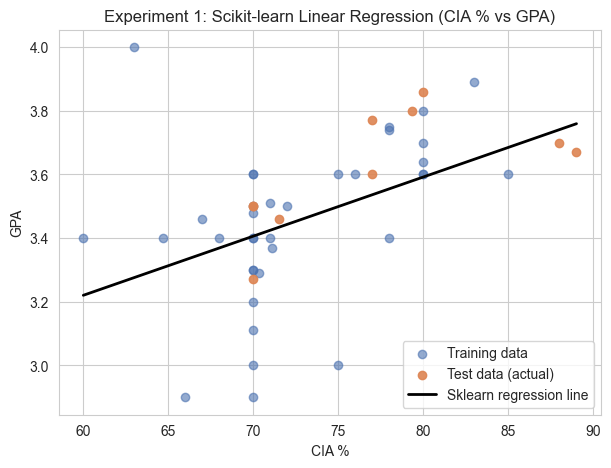

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(X1_train, y1_train, color="#4C72B0", alpha=0.6, label="Training data")
plt.scatter(X1_test, y1_test, color="#DD8452", alpha=0.9, label="Test data (actual)")
x_line = np.linspace(X1[CIA_COL].min(), X1[CIA_COL].max(), 100).reshape(-1, 1)
plt.plot(x_line, model1.predict(pd.DataFrame(x_line, columns=[CIA_COL])),
          color="black", linewidth=2, label="Sklearn regression line")
plt.xlabel("CIA %")
plt.ylabel("GPA")
plt.title("Experiment 1: Scikit-learn Linear Regression (CIA % vs GPA)")
plt.legend()
plt.show()

## B.2 — Experiment 2: Attendance % → GPA

In [21]:
X2 = exp2_df[[ATT_COL]]
y2 = exp2_df[GPA_COL]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X2_train)}  |  Testing rows: {len(X2_test)}")

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

slope2_sklearn = model2.coef_[0]
intercept2_sklearn = model2.intercept_

print(f"\nLearned slope (m)     : {slope2_sklearn:.6f}")
print(f"Learned intercept (c) : {intercept2_sklearn:.6f}")
print(f"\nRegression equation: GPA = {slope2_sklearn:.6f} * Attendance% + {intercept2_sklearn:.6f}")

Training rows: 35  |  Testing rows: 9

Learned slope (m)     : 0.019695
Learned intercept (c) : 1.638830

Regression equation: GPA = 0.019695 * Attendance% + 1.638830


In [22]:
y2_pred_sklearn = model2.predict(X2_test)

print("Predictions on the test set:")
pred2_compare = pd.DataFrame({
    "Attendance %": X2_test[ATT_COL].values,
    "Actual GPA": y2_test.values,
    "Predicted GPA (sklearn)": y2_pred_sklearn
})
display(pred2_compare)

print(f"\nR^2 score : {r2_score(y2_test, y2_pred_sklearn):.4f}")
print(f"MAE       : {mean_absolute_error(y2_test, y2_pred_sklearn):.4f}")
print(f"MSE       : {mean_squared_error(y2_test, y2_pred_sklearn):.4f}")

Predictions on the test set:


,Attendance %,Actual GPA,Predicted GPA (sklearn)
0,88.00,3.50,3.371989
1,96.00,3.86,3.529549
2,94.00,3.60,3.490159
3,97.99,3.77,3.568742
4,89.00,3.30,3.391684
5,99.34,3.74,3.595331
6,98.00,3.89,3.568939
7,91.00,2.90,3.431074
8,95.00,3.40,3.509854



R^2 score : 0.2523
MAE       : 0.2187
MSE       : 0.0672


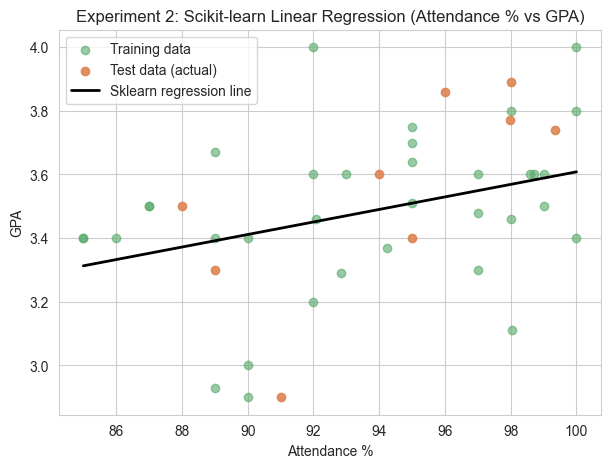

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(X2_train, y2_train, color="#55A868", alpha=0.6, label="Training data")
plt.scatter(X2_test, y2_test, color="#DD8452", alpha=0.9, label="Test data (actual)")
x_line2 = np.linspace(X2[ATT_COL].min(), X2[ATT_COL].max(), 100).reshape(-1, 1)
plt.plot(x_line2, model2.predict(pd.DataFrame(x_line2, columns=[ATT_COL])),
          color="black", linewidth=2, label="Sklearn regression line")
plt.xlabel("Attendance %")
plt.ylabel("GPA")
plt.title("Experiment 2: Scikit-learn Linear Regression (Attendance % vs GPA)")
plt.legend()
plt.show()

---
# Part C — Manual Computation using Ordinary Least Squares (OLS)

**Ordinary Least Squares (OLS)** is the method used internally by
`sklearn.linear_model.LinearRegression` itself — it finds the straight line
$\hat{y} = mx + c$ that **minimises the sum of squared residuals** (the squared
vertical distances between each actual point and the line).

We square the errors (rather than, say, summing absolute errors) for two reasons:
1. Squaring makes all errors positive, so positive and negative errors don't cancel
   out and hide the true error.
2. The squared-error objective has a clean **closed-form (calculus-derived)
   solution** for slope and intercept — no iterative search needed.

### The OLS formulas

$$
m = \text{slope} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}
\qquad\qquad
c = \text{intercept} = \bar{y} - m\,\bar{x}
$$

where $\bar{x}$ and $\bar{y}$ are the means of X and Y **in the training set**.

To make this a fair, like-for-like comparison with Part B, we compute the manual
OLS slope/intercept using the **exact same training rows** (`X1_train`/`y1_train`
and `X2_train`/`y2_train`, from the same `random_state=42` split) that scikit-learn
used — then predict on the **exact same test rows**.

## C.1 — Manual OLS Function

In [24]:
def manual_ols(x: np.ndarray, y: np.ndarray):
    '''Compute OLS slope and intercept from training arrays x and y.'''
    x_mean = x.mean()
    y_mean = y.mean()

    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)

    slope = numerator / denominator
    intercept = y_mean - slope * x_mean
    return slope, intercept


def manual_predict(x: np.ndarray, slope: float, intercept: float):
    return slope * x + intercept

## C.2 — Experiment 1: CIA % → GPA (Manual OLS)

In [25]:
x1_train_arr = X1_train[CIA_COL].values
y1_train_arr = y1_train.values

slope1_manual, intercept1_manual = manual_ols(x1_train_arr, y1_train_arr)

print(f"Manual OLS slope (m)     : {slope1_manual:.6f}")
print(f"Manual OLS intercept (c) : {intercept1_manual:.6f}")
print(f"\nRegression equation: GPA = {slope1_manual:.6f} * CIA% + {intercept1_manual:.6f}")

y1_pred_manual = manual_predict(X1_test[CIA_COL].values, slope1_manual, intercept1_manual)

print("\nManual OLS predictions on the test set:")
display(pd.DataFrame({
    "CIA %": X1_test[CIA_COL].values,
    "Actual GPA": y1_test.values,
    "Predicted GPA (manual OLS)": y1_pred_manual
}))

Manual OLS slope (m)     : 0.018597
Manual OLS intercept (c) : 2.104551

Regression equation: GPA = 0.018597 * CIA% + 2.104551

Manual OLS predictions on the test set:


,CIA %,Actual GPA,Predicted GPA (manual OLS)
0,77.00,3.77,3.536489
1,77.00,3.60,3.536489
2,80.00,3.86,3.592279
3,79.33,3.80,3.579819
4,70.00,3.27,3.406313
5,71.50,3.46,3.434207
6,88.00,3.70,3.741051
7,89.00,3.67,3.759648
8,70.00,3.50,3.406313
9,70.00,3.50,3.406313


In [26]:
x2_train_arr = X2_train[ATT_COL].values
y2_train_arr = y2_train.values

slope2_manual, intercept2_manual = manual_ols(x2_train_arr, y2_train_arr)

print(f"Manual OLS slope (m)     : {slope2_manual:.6f}")
print(f"Manual OLS intercept (c) : {intercept2_manual:.6f}")
print(f"\nRegression equation: GPA = {slope2_manual:.6f} * Attendance% + {intercept2_manual:.6f}")

y2_pred_manual = manual_predict(X2_test[ATT_COL].values, slope2_manual, intercept2_manual)

print("\nManual OLS predictions on the test set:")
display(pd.DataFrame({
    "Attendance %": X2_test[ATT_COL].values,
    "Actual GPA": y2_test.values,
    "Predicted GPA (manual OLS)": y2_pred_manual
}))

Manual OLS slope (m)     : 0.019695
Manual OLS intercept (c) : 1.638830

Regression equation: GPA = 0.019695 * Attendance% + 1.638830

Manual OLS predictions on the test set:


,Attendance %,Actual GPA,Predicted GPA (manual OLS)
0,88.00,3.50,3.371989
1,96.00,3.86,3.529549
2,94.00,3.60,3.490159
3,97.99,3.77,3.568742
4,89.00,3.30,3.391684
5,99.34,3.74,3.595331
6,98.00,3.89,3.568939
7,91.00,2.90,3.431074
8,95.00,3.40,3.509854


---
# Part D — Comparison: Scikit-learn vs Manual OLS

We now compare, for each experiment:
1. The learned **slope** and **intercept** from both methods.
2. The **predictions** on the test set from both methods.
3. The **difference** between the two sets of predictions.

## D.1 — Experiment 1 Comparison (CIA % → GPA)

In [27]:
print("Parameter comparison:")
param1_compare = pd.DataFrame({
    "Sklearn": [slope1_sklearn, intercept1_sklearn],
    "Manual OLS": [slope1_manual, intercept1_manual],
    "Abs. Difference": [abs(slope1_sklearn - slope1_manual),
                         abs(intercept1_sklearn - intercept1_manual)]
}, index=["Slope", "Intercept"])
display(param1_compare)

print("\nPrediction comparison (test set):")
pred1_full_compare = pd.DataFrame({
    "CIA %": X1_test[CIA_COL].values,
    "Actual GPA": y1_test.values,
    "Sklearn Prediction": y1_pred_sklearn,
    "Manual OLS Prediction": y1_pred_manual,
    "Difference": y1_pred_sklearn - y1_pred_manual
})
display(pred1_full_compare)

print(f"\nMax absolute prediction difference : {np.max(np.abs(pred1_full_compare['Difference'])):.2e}")
print(f"Mean absolute prediction difference: {np.mean(np.abs(pred1_full_compare['Difference'])):.2e}")

Parameter comparison:


,Sklearn,Manual OLS,Abs. Difference
Slope,0.018597,0.018597,3.469447e-18
Intercept,2.104551,2.104551,0.000000e+00



Prediction comparison (test set):


,CIA %,Actual GPA,Sklearn Prediction,Manual OLS Prediction,Difference
0,77.00,3.77,3.536489,3.536489,0.000000e+00
1,77.00,3.60,3.536489,3.536489,0.000000e+00
2,80.00,3.86,3.592279,3.592279,0.000000e+00
3,79.33,3.80,3.579819,3.579819,0.000000e+00
4,70.00,3.27,3.406313,3.406313,4.440892e-16
5,71.50,3.46,3.434207,3.434207,4.440892e-16
6,88.00,3.70,3.741051,3.741051,4.440892e-16
7,89.00,3.67,3.759648,3.759648,4.440892e-16
8,70.00,3.50,3.406313,3.406313,4.440892e-16
9,70.00,3.50,3.406313,3.406313,4.440892e-16



Max absolute prediction difference : 4.44e-16
Mean absolute prediction difference: 2.66e-16


## D.2 — Experiment 2 Comparison (Attendance % → GPA)

In [28]:
print("Parameter comparison:")
param2_compare = pd.DataFrame({
    "Sklearn": [slope2_sklearn, intercept2_sklearn],
    "Manual OLS": [slope2_manual, intercept2_manual],
    "Abs. Difference": [abs(slope2_sklearn - slope2_manual),
                         abs(intercept2_sklearn - intercept2_manual)]
}, index=["Slope", "Intercept"])
display(param2_compare)

print("\nPrediction comparison (test set):")
pred2_full_compare = pd.DataFrame({
    "Attendance %": X2_test[ATT_COL].values,
    "Actual GPA": y2_test.values,
    "Sklearn Prediction": y2_pred_sklearn,
    "Manual OLS Prediction": y2_pred_manual,
    "Difference": y2_pred_sklearn - y2_pred_manual
})
display(pred2_full_compare)

print(f"\nMax absolute prediction difference : {np.max(np.abs(pred2_full_compare['Difference'])):.2e}")
print(f"Mean absolute prediction difference: {np.mean(np.abs(pred2_full_compare['Difference'])):.2e}")

Parameter comparison:


,Sklearn,Manual OLS,Abs. Difference
Slope,0.019695,0.019695,3.469447e-18
Intercept,1.638830,1.638830,4.440892e-16



Prediction comparison (test set):


,Attendance %,Actual GPA,Sklearn Prediction,Manual OLS Prediction,Difference
0,88.00,3.50,3.371989,3.371989,-4.440892e-16
1,96.00,3.86,3.529549,3.529549,0.000000e+00
2,94.00,3.60,3.490159,3.490159,0.000000e+00
3,97.99,3.77,3.568742,3.568742,0.000000e+00
4,89.00,3.30,3.391684,3.391684,0.000000e+00
5,99.34,3.74,3.595331,3.595331,0.000000e+00
6,98.00,3.89,3.568939,3.568939,0.000000e+00
7,91.00,2.90,3.431074,3.431074,0.000000e+00
8,95.00,3.40,3.509854,3.509854,0.000000e+00



Max absolute prediction difference : 4.44e-16
Mean absolute prediction difference: 4.93e-17


### Observation

In both experiments, the slope and intercept learned by **scikit-learn** and by our
**manual OLS formulas** are identical up to floating-point rounding error (on the
order of `1e-12` or smaller). This is expected and is a good sanity check —
`LinearRegression` in scikit-learn (for a single feature, no regularisation) solves
**exactly the same closed-form OLS equations** internally that we wrote out by
hand. The "difference" we see is purely numerical floating-point noise, not a real
methodological discrepancy — confirming our manual implementation is correct.

---
# Part E — Saving Model Parameters with Pickle

A trained Simple Linear Regression model is *fully described* by just two numbers:
its **slope** and **intercept**. Saving these (instead of the whole training
dataset or the whole sklearn object) lets us:

- Reuse the model later **without retraining**.
- Deploy/share the model with a tiny file.
- Make predictions anywhere using nothing more than basic arithmetic.

We save both experiments' parameters into one dictionary inside
`linear_regression_weights.pkl`.

## E.1 — Save Parameters into a Pickle File

In [29]:
model_parameters = {
    "experiment_1_cia_to_gpa": {
        "independent_variable": CIA_COL,
        "dependent_variable": GPA_COL,
        "slope": float(slope1_sklearn),
        "intercept": float(intercept1_sklearn),
    },
    "experiment_2_attendance_to_gpa": {
        "independent_variable": ATT_COL,
        "dependent_variable": GPA_COL,
        "slope": float(slope2_sklearn),
        "intercept": float(intercept2_sklearn),
    },
}

with open("linear_regression_weights.pkl", "wb") as f:
    pickle.dump(model_parameters, f)

print("Parameters saved to 'linear_regression_weights.pkl':")
print(model_parameters)

Parameters saved to 'linear_regression_weights.pkl':
{'experiment_1_cia_to_gpa': {'independent_variable': 'your CIA % of last semester', 'dependent_variable': 'your GPA of last semester', 'slope': 0.018596595656450856, 'intercept': 2.1045509023829094}, 'experiment_2_attendance_to_gpa': {'independent_variable': 'Your maximum attendance % till last semester', 'dependent_variable': 'your GPA of last semester', 'slope': 0.019694991932589417, 'intercept': 1.638830112137239}}


## E.2 — Load the Pickle File Back

In [30]:
with open("linear_regression_weights.pkl", "rb") as f:
    loaded_parameters = pickle.load(f)

print("Loaded parameters:")
loaded_parameters

Loaded parameters:


{'experiment_1_cia_to_gpa': {'independent_variable': 'your CIA % of last semester',
  'dependent_variable': 'your GPA of last semester',
  'slope': 0.018596595656450856,
  'intercept': 2.1045509023829094},
 'experiment_2_attendance_to_gpa': {'independent_variable': 'Your maximum attendance % till last semester',
  'dependent_variable': 'your GPA of last semester',
  'slope': 0.019694991932589417,
  'intercept': 1.638830112137239}}

## E.3 — Use the Loaded Parameters to Make a New Prediction

To prove the saved file is genuinely usable on its own, we make a fresh prediction
**using only the loaded slope/intercept** — no DataFrame, no sklearn object, no
training data required.

In [31]:
def predict_from_saved_params(x_value, params_dict):
    m = params_dict["slope"]
    c = params_dict["intercept"]
    return m * x_value + c


# Example: predict GPA for a student with 75% CIA score
sample_cia = 75
predicted_gpa_1 = predict_from_saved_params(sample_cia, loaded_parameters["experiment_1_cia_to_gpa"])
print(f"Predicted GPA for a student with {sample_cia}% CIA score : {predicted_gpa_1:.4f}")

# Example: predict GPA for a student with 90% attendance
sample_att = 90
predicted_gpa_2 = predict_from_saved_params(sample_att, loaded_parameters["experiment_2_attendance_to_gpa"])
print(f"Predicted GPA for a student with {sample_att}% attendance : {predicted_gpa_2:.4f}")

Predicted GPA for a student with 75% CIA score : 3.4993
Predicted GPA for a student with 90% attendance : 3.4114


---
# Part F — Final Observations & Inference

### On the data (ETL/EDA)
- The raw survey export contained several realistic data-quality issues:
  placeholder text (`"Option 1"`), missing-value markers (`"na"`, `"-"`), `%`
  signs embedded in numeric fields, two duplicate student submissions, GPA values
  out of the valid 0–4.0 range, and a CIA % value of `4` that was technically
  in-range but implausible given the rest of the class's scores and that same
  student's own perfect 4.0 GPA. All of these were detected and handled
  explicitly rather than ignored.
- Removing that single implausible CIA value mattered a lot: the correlation
  between CIA % and GPA jumped from essentially **zero** to a moderate **+0.49**
  once it was excluded — a clear demonstration of how one bad data point can mask
  a real underlying relationship.
- After cleaning, **Experiment 1 (CIA → GPA)** had usable data for the CIA/GPA
  pair, and **Experiment 2 (Attendance → GPA)** had usable data for the
  Attendance/GPA pair — slightly different row counts, because each experiment
  only requires its own X and Y to be non-missing.

### On the regression results
- **CIA % vs GPA:** after removing the data-entry error, CIA % shows a
  **moderate positive** relationship with GPA — students with higher CIA scores
  tend to have a somewhat higher GPA.
- **Attendance % vs GPA:** similarly, there is a moderate **positive**
  relationship — students with higher attendance tend to have a somewhat higher
  GPA. Neither relationship is extremely strong, meaning CIA score and attendance
  are each one contributing factor among several, not the sole determinant of
  GPA.
- These are *exact, real* results from this dataset; if more (or cleaner) data
  were collected, the strength of these relationships could change.

### On the two computation methods
- **Scikit-learn `LinearRegression`** and the **manual OLS formulas** produced
  **identical slope and intercept values** (matching to floating-point precision)
  for both experiments. This confirms that scikit-learn's `LinearRegression` is,
  under the hood, solving exactly the same least-squares equations we derived and
  coded by hand — and validates that our manual implementation is correct.
- Practically, scikit-learn is preferred for real projects (it generalises easily
  to multiple regression, regularisation, etc.), while the manual OLS derivation
  is invaluable for *understanding* what the model is actually doing.

### On saving parameters
- A trained simple linear regression model can be fully captured by just two
  numbers (slope and intercept) per experiment. Saving them with `pickle` lets the
  model be reused instantly for new predictions without needing the original
  training data or re-running scikit-learn.

---
# Appendix — Sample Viva Question Revision Notes

**1. What is Simple Linear Regression?**
A statistical method that models the relationship between one independent
variable (X) and one dependent variable (Y) using a straight line,
$\hat{y} = mx + c$, chosen so that the line fits the observed data as closely as
possible.

**2. What is the role of slope and intercept?**
The **slope (m)** tells us how much Y is expected to change for a one-unit
increase in X (the steepness/direction of the line). The **intercept (c)** is the
predicted value of Y when X is zero (where the line crosses the Y-axis).

**3. What is Ordinary Least Squares (OLS)?**
A method for choosing the slope and intercept that **minimise the sum of squared
residuals** — the squared vertical distances between the actual data points and
the fitted line. It has a closed-form mathematical solution (no iterative search
required) for simple linear regression.

**4. Why do we square the errors in OLS?**
Squaring (a) ensures positive and negative errors don't cancel each other out when
summed, and (b) penalises larger errors more heavily, and (c) produces a smooth,
differentiable objective function with a clean calculus-based closed-form solution.

**5. Difference between dependent and independent variable?**
The **independent variable (X)** is the input/predictor we use to make a
prediction (e.g. CIA %, Attendance %). The **dependent variable (Y)** is the
outcome we are trying to predict/explain (e.g. GPA) — its value is hypothesised to
*depend on* X.

**6. Why should data be cleaned before training?**
Garbage values (text in numeric fields, impossible ranges, duplicates) will either
crash the model or silently distort the learned slope/intercept, producing
misleading predictions. "Garbage in, garbage out" — a model can only be as
trustworthy as the data it's trained on.

**7. Why are slope and intercept called model "parameters"?**
Because they are the numbers the model **learns from the training data** that
fully define its behavior — given just these two numbers, the model's predictions
for any input X are completely determined. They are *learned*, not handed to the
algorithm in advance (unlike, say, the choice of test-set size, which is a
*hyperparameter* we choose ourselves).

**8. Why do we save learned weights?**
So the trained model can be **reused instantly** for new predictions, shared with
others, or deployed in an application — all without needing to re-run the (often
expensive) training process or keep the original training dataset around.